# Wall-Correction Comparison -- Prop-Off & Prop-On

Compares **raw / uncorrected** coefficients against **wall-corrected (FINAL)** values.  
For prop-on force coefficients, a **BEM thrust-corrected** intermediate layer is also shown.

**Linestyle convention** (same across all plots):
- `--` dashed  -- raw / uncorrected
- `:` dotted   -- BEM thrust-corrected (prop-on force coefficients only)
- `-` solid    -- fully corrected (FINAL)

**Marker convention**:
- `o` circle   -- raw / uncorrected
- `^` triangle -- BEM thrust-corrected
- `s` square   -- fully corrected (FINAL)

**Colour** encodes J value (prop-on combined plots); correction layer is encoded by linestyle/marker.

**Sections**  
1. Setup & data loading  
2. Prop-Off (CL, CD, polar, CYaw, CMpitch, delta-alpha shift, multi-beta sweep)  
3. Prop-On (per-J individual figures + combined J=1.6/2.4 figures; polar overlay; delta increments)

## 1  Setup

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ── Paths — update to match your directory layout ─────────────────────────────
df_on  = pd.read_csv(r"CORRECTIONS_FINAL\results_propOn_FINAL\propOn_final.csv")
df_on_BEM = pd.read_csv(r"CORRECTIONS_FINAL\results_propOn_FINAL\propOn_final_BEM.csv")
df_off = pd.read_csv(r"CORRECTIONS_FINAL\results_propOff_FINAL\propOff_final.csv")

# ── Global plot settings ──────────────────────────────────────────────────────
SAVE_FORMAT = "pdf"         # "pdf" for LaTeX/report figures, "png" if needed
J_VALUES_PLOT = []  # J values to include in plots (full alpha sweeps available)
FIGSIZE_COMP = (8, 5)
FIGSIZE_COMP_GRID = (16,8) #ORIGINAL (14,9)
SAVE_RES   = 600
SHOW_TITLE = False
PLOT_PROPOFF_ON_J_PLOTS = True   # overlay prop-off corrected line on per-J and combined figures
PLOT_DIR   = os.path.join(os.path.dirname(os.path.abspath("__file__")),
                          "correction_comparison_plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# ── Global font / style settings ──────────────────────────────────────────────
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "Latin Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",

    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 12,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "legend.frameon": True,
})

# ── Marker convention ─────────────────────────────────────────────────────────
MK_RAW = "o"   # raw / uncorrected
MK_BEM = "^"   # BEM thrust-corrected (prop-on only)
MK_COR = "s"   # fully corrected FINAL
MS     = 5     # marker size

# ── Linestyle convention ──────────────────────────────────────────────────────
LS_RAW = "--"  # raw / uncorrected
LS_BEM = ":"   # BEM thrust-corrected
LS_COR = "-"   # fully corrected FINAL

def savefig(fig, name, subfolder=None, transparent=False, bbox_extra_artists=None):
    save_dir = PLOT_DIR if subfolder is None else os.path.join(PLOT_DIR, subfolder)
    os.makedirs(save_dir, exist_ok=True)

    ext = SAVE_FORMAT.lower().strip(".")
    path = os.path.join(save_dir, f"{name}.{ext}")

    kwargs = dict(transparent=transparent, bbox_inches="tight")
    if bbox_extra_artists:
        kwargs["bbox_extra_artists"] = bbox_extra_artists
    if ext in {"png", "jpg", "jpeg", "tif", "tiff"}:
        kwargs["dpi"] = SAVE_RES

    fig.savefig(path, **kwargs)
    print(f"Saved figure to: {path}")

In [43]:
# ── Colour palette — uncomment one line to switch all plots ──────────────────
import seaborn as sns

# PALETTE = "colorblind"  # accessible, best for publication (default)
# PALETTE = "muted"       # soft, good for reports
# PALETTE = "deep"        # richer / bolder
# PALETTE = "tab10"       # matplotlib default
PALETTE = "colorblind"

COLORS = sns.color_palette(PALETTE).as_hex()
print(f"Using palette: {PALETTE}")
print(f"Colours: {COLORS}")

Using palette: colorblind
Colours: ['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc', '#ca9161', '#fbafe4', '#949494', '#ece133', '#56b4e9']


In [44]:
# ── Rounded helper columns ────────────────────────────────────────────────────
for _df in [df_on, df_off]:
    if "V_round"   not in _df.columns: _df["V_round"]   = _df["V"].round()
    if "AoS_round" not in _df.columns: _df["AoS_round"] = _df["AoS"].round()
    if "AoA_round" not in _df.columns: _df["AoA_round"] = _df["AoA"].round(1)

if "J_round" not in df_on.columns:
    df_on["J_round"] = df_on["J"].round(1)

# ── J values used in combined prop-on plots ───────────────────────────────────
J_COMBINED = [1.6, 2.4]   # only these two J values on combined figures

print("df_off shape:", df_off.shape)
print("df_on  shape:", df_on.shape)
print("Prop-off AoS values:", sorted(df_off["AoS_round"].unique()))
print("Prop-off dR  values:", sorted(df_off["dR"].unique()))
print("Prop-on  J   values:", sorted(df_on["J_round"].unique()))
print("Prop-on  dR  values:", sorted(df_on["dR"].unique()))

df_off shape: (4409, 68)
df_on  shape: (55, 157)
Prop-off AoS values: [np.float64(-10.0), np.float64(-8.0), np.float64(-5.0), np.float64(-4.0), np.float64(0.0), np.float64(4.0), np.float64(5.0), np.float64(7.0), np.float64(8.0), np.float64(10.0)]
Prop-off dR  values: [np.int64(-20), np.int64(-10), np.int64(0), np.int64(10), np.int64(20)]
Prop-on  J   values: [np.float64(1.6), np.float64(2.0), np.float64(2.4), np.float64(2.8)]
Prop-on  dR  values: [np.float64(-20.0), np.float64(-10.0), np.float64(-5.0), np.float64(0.0)]


----
----
# Final comparison plots
---


## Prop off
---

### Prop-off AoA sweep, $V=40$ (NEW)


Prop-off: 14 rows, AoA range -5.0–14.0


C:\Users\douwe\AppData\Local\Temp\ipykernel_24560\1912698583.py:250: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, LEG_LEFT - 0.01, 1.0])


Saved figure to: c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\correction_comparison_plots\propoff_4coeff_correction_stages.pdf


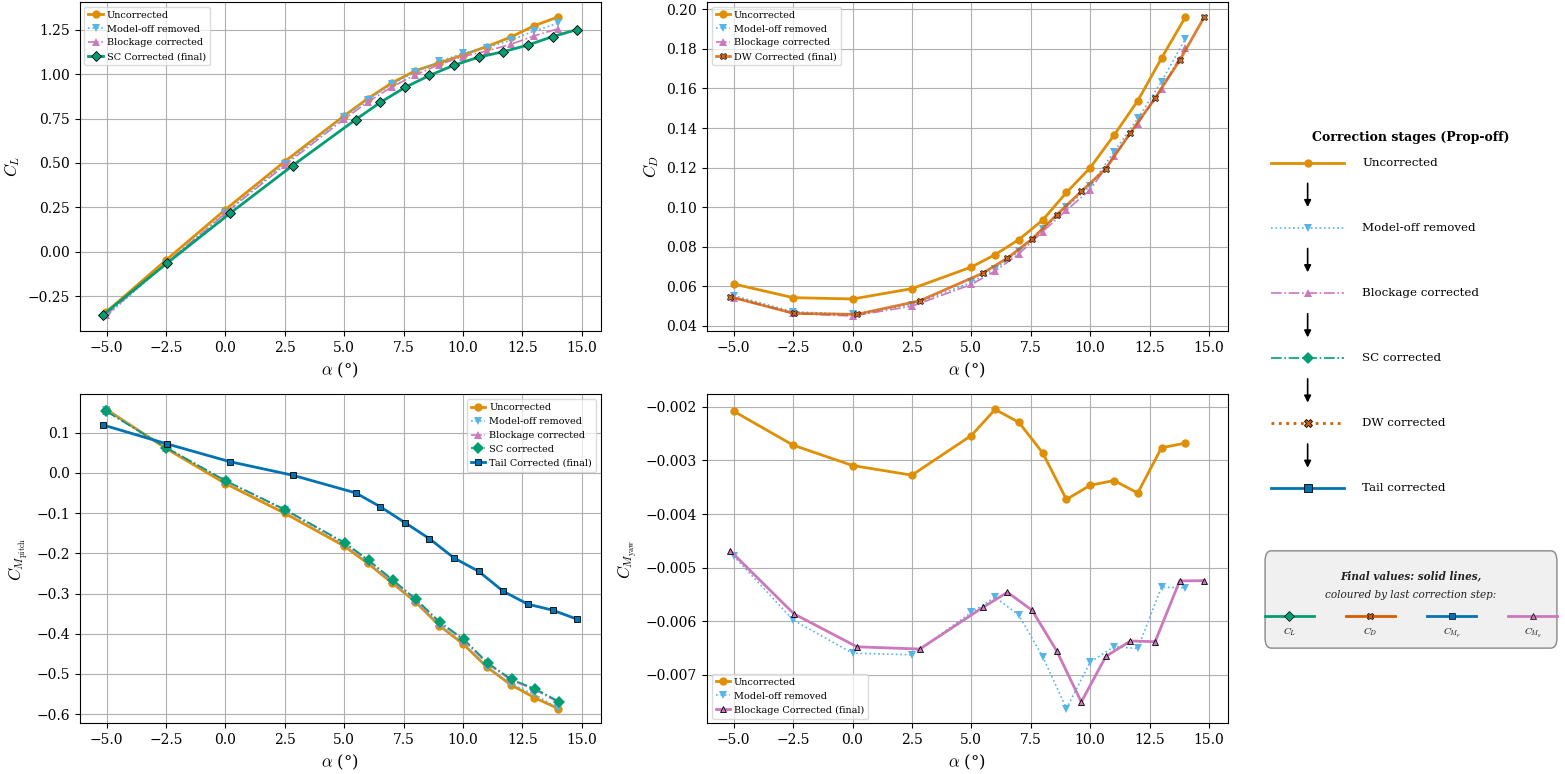

In [53]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
# ═══════════════════════════════════════════════════════════════════════════════
# ── Prop-off: 4 key coefficients with intermediate correction steps ────────────
# AoS=0, V=40, dR=0, dE=0
# ═══════════════════════════════════════════════════════════════════════════════
def draw_flow_legend(fig, leg_entries, footer_finals, leg_left=0.795):
    from matplotlib.patches import FancyBboxPatch
 
    n_entries  = len(leg_entries)
    leg_ax = fig.add_axes([leg_left, 0.18, 0.19, 0.64])
    leg_ax.set_xlim(0, 1)
    leg_ax.set_ylim(0, 1)
    leg_ax.axis("off")
 
    # Title
    leg_ax.text(0.5, 1.0, "Correction stages (Prop-off)", ha="center", va="top",
                fontsize=9, fontweight="bold", transform=leg_ax.transAxes)
 
    # Flow entries
    flow_region = 0.70
    total_slots = n_entries + (n_entries - 1)
    slot_h      = flow_region / total_slots
    y_start     = 0.97
 
    entry_ys = []
    for k in range(total_slots):
        y_centre = y_start - k * slot_h - slot_h / 2
        if k % 2 == 0:
            entry_ys.append(y_centre)
 
    for idx, ((lbl, sty, is_fin), y_c) in enumerate(zip(leg_entries, entry_ys)):
        line_x = [0.04, 0.28]
        leg_ax.plot(line_x, [y_c, y_c],
                    color=sty["color"],
                    linestyle=sty["linestyle"],
                    linewidth=2.0 if is_fin or idx == 0 else 1.2,
                    transform=leg_ax.transAxes, clip_on=False)
        leg_ax.plot([np.mean(line_x)], [y_c],
                    marker=sty["marker"], markersize=6,
                    markerfacecolor=sty["color"],
                    markeredgecolor="black" if is_fin else sty["color"],
                    markeredgewidth=0.6 if is_fin else 0.0,
                    color=sty["color"],
                    transform=leg_ax.transAxes, clip_on=False, linestyle="none")
        leg_ax.text(0.34, y_c, lbl, va="center", ha="left",
                    fontsize=8.5, transform=leg_ax.transAxes)
 
        if idx < n_entries - 1:
            arrow_y_top    = y_c - slot_h * 0.55
            arrow_y_bottom = y_c - slot_h * 1.45
            leg_ax.annotate("",
                xy=(0.16, arrow_y_bottom), xytext=(0.16, arrow_y_top),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2, mutation_scale=10))
 
    # Footer box
    footer_box = FancyBboxPatch(
        (0.04, 0.01), 0.92, 0.15,
        boxstyle="round,pad=0.02", transform=leg_ax.transAxes,
        facecolor="#f0f0f0", edgecolor="#888888", linewidth=1.0,
        clip_on=False, zorder=2)
    leg_ax.add_patch(footer_box)
 
    leg_ax.text(0.5, 0.132, "Final values: solid lines,",
        ha="center", va="center", fontsize=7.5, fontstyle="italic",
        fontweight="bold", color="#222222", transform=leg_ax.transAxes, zorder=3)
    leg_ax.text(0.5, 0.094, "coloured by last correction step:",
        ha="center", va="center", fontsize=7.5, fontstyle="italic",
        color="#222222", transform=leg_ax.transAxes, zorder=3)
 
    n_sw    = len(footer_finals)
    swatch_y = 0.040
    for k, (lbl, sty) in enumerate(footer_finals):
        x_c = 0.1 + k * (0.8 / (n_sw - 1))
        leg_ax.plot([x_c - 0.08, x_c + 0.08], [swatch_y + 0.012, swatch_y + 0.012],
                    color=sty["color"], linewidth=2.0,
                    transform=leg_ax.transAxes, zorder=3, clip_on=False)
        leg_ax.plot([x_c], [swatch_y + 0.012],
                    marker=sty["marker"], markersize=5,
                    markerfacecolor=sty["color"],
                    markeredgecolor="black", markeredgewidth=0.5,
                    linestyle="none", color=sty["color"],
                    transform=leg_ax.transAxes, zorder=4, clip_on=False)
        leg_ax.text(x_c, swatch_y - 0.006, lbl,
                    ha="center", va="top", fontsize=7,
                    transform=leg_ax.transAxes, zorder=3)
 
    # Border
    for spine in ["top", "bottom", "left", "right"]:
        leg_ax.spines[spine].set_visible(True)
        leg_ax.spines[spine].set_linewidth(0.6)
        leg_ax.spines[spine].set_color("#cccccc")
 
    return leg_ax
    
# ── Helper: draw the right-side flow legend (reusable) ────────────────────────
# ── Prop-off stage styles (no thrust-removed step) ───────────────────────────
_STAGE_STYLES_OFF = [
    dict(marker="o", linestyle="-",  color=COLORS[1]),   # 0 uncorrected  orange
    dict(marker="v", linestyle=":",  color=COLORS[9]),   # 1 model-off    teal
    dict(marker="^", linestyle="-.", color=COLORS[4]),   # 2 blockage     purple
    dict(marker="D", linestyle="-.", color=COLORS[2]),   # 3 SC           green
    dict(marker="s", linestyle="-",  color=COLORS[0]),   # 4 tail/final   blue
]
# DW reuses same style as prop-on
_DW_STYLE_OFF = dict(marker="X", linestyle=":", color=COLORS[3])
 
_COEFF_CONFIG_OFF = [
    (
        r"$C_L$", 3,          # final style idx → SC green (index 3)
        [
            ("Uncorrected",          "raw", "CL_uncorrected"),
            ("Model-off removed",    "raw", "CL"),
            ("Blockage corrected",   "raw", "CL_blockage_corr"),
            ("SC Corrected (final)", "fin", "CL_FINAL"),
        ]
    ),
    (
        r"$C_D$", 3,          # final style idx → overridden by DW check
        [
            ("Uncorrected",          "raw", "CD_uncorrected"),
            ("Model-off removed",    "raw", "CD"),
            ("Blockage corrected",   "raw", "CD_blockage_corr"),
            ("DW Corrected (final)", "fin", "CD_FINAL"),
        ]
    ),
    (
        r"$C_{M_\mathrm{pitch}}$", 4,   # final style idx → tail blue (index 4)
        [
            ("Uncorrected",            "raw", "CMpitch_uncorrected"),
            ("Model-off removed",      "raw", "CMpitch"),
            ("Blockage corrected",     "raw", "CMpitch_blockage_corr"),
            ("SC corrected",           "sc", "CMpitch_blockage_corr_sc_corr"),
            ("Tail Corrected (final)", "fin", "CMpitch_FINAL"),
        ]
    ),
    (
        r"$C_{M_\mathrm{yaw}}$", 2,   # final style idx → blockage purple (index 2)
        [
            ("Uncorrected",                "raw", "CMyaw_uncorrected"),
            ("Model-off removed",          "raw", "CMyaw"),
            ("Blockage Corrected (final)", "fin", "CMyaw_FINAL"),
        ]
    ),
]
 
# Flow legend entries for prop-off (no thrust-removed row)
_FIG_LEGEND_ENTRIES_OFF = [
    ("Uncorrected",                  _STAGE_STYLES_OFF[0], False),
    ("Model-off removed",            _STAGE_STYLES_OFF[1], False),
    ("Blockage corrected",           _STAGE_STYLES_OFF[2], False),
    ("SC corrected",                 _STAGE_STYLES_OFF[3], False),
    (r"DW corrected", _DW_STYLE_OFF,        True),
    ("Tail corrected",       _STAGE_STYLES_OFF[4], True),
]
 
_FOOTER_FINALS_OFF = [
    (r"$C_L$",     _STAGE_STYLES_OFF[3]),   # SC    → green
    (r"$C_D$",     _DW_STYLE_OFF),          # DW    → dark red
    (r"$C_{M_p}$", _STAGE_STYLES_OFF[4]),   # Tail  → blue
    (r"$C_{M_y}$", _STAGE_STYLES_OFF[2]),   # BLK   → purple
]
 
# ── Filter & plot ─────────────────────────────────────────────────────────────
_df_off = df_off[
    (df_off["V_round"]   == 40) &
    (df_off["AoS_round"] == 0)  &
    (df_off["dR"]        == 0)  &
    (df_off["dE"]        == 0)
].copy()
 
# Average duplicate AoA points
_df_off = (
    _df_off.groupby("AoA_round", as_index=False)
    .mean(numeric_only=True)
    .sort_values("AoA_round")
)
 
print(f"\nProp-off: {len(_df_off)} rows, AoA range {_df_off['AoA'].min():.1f}–{_df_off['AoA'].max():.1f}")
 
_x_raw_off = _df_off["AoA"].to_numpy(dtype=float)
_x_fin_off = _df_off["AoA_FINAL"].to_numpy(dtype=float)
# Add alongside _x_raw_off / _x_fin_off:
_x_sc_off = _df_off["AoA_sc_corr"].to_numpy(dtype=float)

LEG_LEFT = 0.795
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_COMP_GRID)
axes = axes.flatten()
 
for ax, (ylabel, final_style_idx, stages) in zip(axes, _COEFF_CONFIG_OFF):
    for i, (label, x_key, col) in enumerate(stages):
        if col not in _df_off.columns:
            print(f"  WARNING: column '{col}' not found, skipping")
            continue

        # In the plotting dispatch:
        if   x_key == "fin": x = _x_fin_off
        elif x_key == "sc":  x = _x_sc_off
        else:                x = _x_raw_off
 
        y = _df_off[col].to_numpy(dtype=float)
        fin = np.isfinite(x) & np.isfinite(y)
 
        if fin.sum() == 0:
            print(f"  WARNING: no finite data for {col}")
            continue
 
        is_final = (i == len(stages) - 1)
        is_start = (i == 0)
 
        style = (
            _STAGE_STYLES_OFF[final_style_idx] if is_final and "DW" not in label
            else _DW_STYLE_OFF if "DW" in label
            else _STAGE_STYLES_OFF[i]
        )

        ax.plot(
            x[fin], y[fin],
            marker=style["marker"],
            markersize=MS if not is_final else MS - 1,
            markerfacecolor=style["color"],
            markeredgecolor="black" if is_final else style["color"],
            markeredgewidth=0.6 if is_final else 0.0,
            linestyle="-" if is_final or is_start else style["linestyle"],
            color=style["color"],
            linewidth=2.0 if is_final or is_start else 1.2,
            label=label,
            alpha=0.8 if "DW" in label else 1.0,
        )
 
    ax.set_xlabel(r"$\alpha$ (°)")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, loc="best", framealpha=0.7,
              handlelength=1.5, handletextpad=0.4, borderpad=0.4)
    ax.grid(True)
 
leg_ax = draw_flow_legend(fig, _FIG_LEGEND_ENTRIES_OFF, _FOOTER_FINALS_OFF, leg_left=LEG_LEFT) 

if SHOW_TITLE:
    plt.suptitle(
        r"Prop-off correction stages — $V$ = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°, $\delta_e$ = 0°",
        fontsize=12, y=1.01
    )
 
plt.tight_layout(rect=[0, 0, LEG_LEFT - 0.01, 1.0])
savefig(fig, "propoff_4coeff_correction_stages", bbox_extra_artists=[leg_ax])
plt.show()


---
###  Prop-off AoS sweep, $V=40$

Prop-off β sweep: 9 rows, AoS range -10.0–10.0


C:\Users\douwe\AppData\Local\Temp\ipykernel_24560\784257955.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, LEG_LEFT - 0.01, 1.0])


Saved figure to: c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\correction_comparison_plots\propoff_CL_CMyaw_beta_sweep.pdf


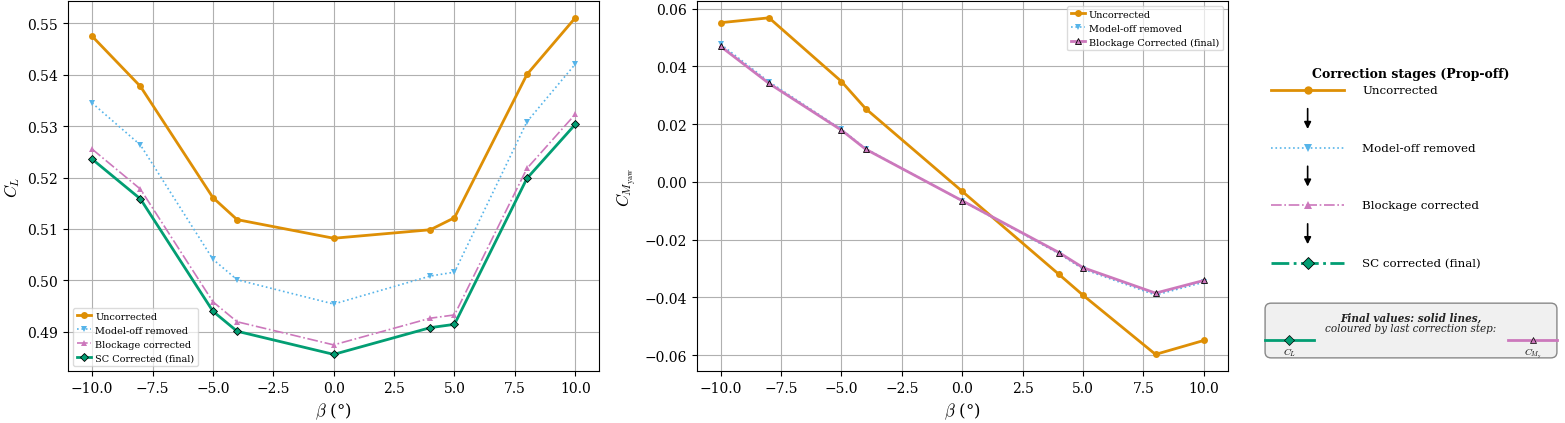


CMyaw model-off correction effect:
   β (°)         Raw   Model-off removed    Δ (signed)         |Δ|        Δ%
────────────────────────────────────────────────────────────────────────────────
   -10.0     0.05515             0.04770      -0.00745     0.00745    -13.5%
    -8.0     0.05683             0.03468      -0.02215     0.02215    -39.0%
    -5.0     0.03477             0.01822      -0.01655     0.01655    -47.6%
    -4.0     0.02538             0.01153      -0.01385     0.01385    -54.6%
     0.0    -0.00327            -0.00662      -0.00335     0.00335   -102.3%
     4.0    -0.03199            -0.02484       0.00715     0.00715     22.3%
     5.0    -0.03923            -0.03018       0.00905     0.00905     23.1%
     8.0    -0.05972            -0.03917       0.02055     0.02055     34.4%
    10.0    -0.05489            -0.03474       0.02015     0.02015     36.7%
────────────────────────────────────────────────────────────────────────────────
                                

In [46]:
# ═══════════════════════════════════════════════════════════════════════════════
# ── Prop-off: CL and CMyaw β sweep with intermediate correction steps ──────────
# AoA=2.5, V=40, dR=0, dE=0
# ═══════════════════════════════════════════════════════════════════════════════

# ── Coefficient config ────────────────────────────────────────────────────────

_COEFF_CONFIG_BETA_OFF = [
    (
        r"$C_L$", 3,          # final style idx → SC green
        [
            ("Uncorrected",          "raw", "CL_uncorrected"),
            ("Model-off removed",    "raw", "CL"),
            ("Blockage corrected",   "raw", "CL_blockage_corr"),
            ("SC Corrected (final)", "fin", "CL_FINAL"),
        ]
    ),
    (
        r"$C_{M_\mathrm{yaw}}$", 2,   # final style idx → blockage purple
        [
            ("Uncorrected",                "raw", "CMyaw_uncorrected"),
            ("Model-off removed",          "raw", "CMyaw"),
            ("Blockage Corrected (final)", "fin", "CMyaw_FINAL"),
        ]
    ),
]

# Flow legend entries — only the stages that actually appear across both panels
_FIG_LEGEND_ENTRIES_BETA_OFF = [
    ("Uncorrected",          _STAGE_STYLES_OFF[0], False),
    ("Model-off removed",    _STAGE_STYLES_OFF[1], False),
    ("Blockage corrected",   _STAGE_STYLES_OFF[2], False),
    ("SC corrected (final)", _STAGE_STYLES_OFF[3], True),
]

# Footer swatches — one per coefficient, coloured by its final correction step
_FOOTER_FINALS_BETA_OFF = [
    (r"$C_L$",              _STAGE_STYLES_OFF[3]),   # SC    → green
    (r"$C_{M_\mathrm{y}}$", _STAGE_STYLES_OFF[2]),   # BLK   → purple
]

# ── Load & filter ─────────────────────────────────────────────────────────────

_df_off_beta = df_off[
    (df_off["V_round"]   == 40)  &
    (df_off["AoA_round"] == 2.5) &
    (df_off["dR"]        == 0)   &
    (df_off["dE"]        == 0)
].copy()

# Average duplicate AoS points
_df_off_beta = (
    _df_off_beta.groupby("AoS_round", as_index=False)
    .mean(numeric_only=True)
    .sort_values("AoS_round")
)

print(f"Prop-off β sweep: {len(_df_off_beta)} rows, "
      f"AoS range {_df_off_beta['AoS_round'].min():.1f}–{_df_off_beta['AoS_round'].max():.1f}")

_x_raw_off_beta = _df_off_beta["AoS_round"].to_numpy(dtype=float)
_x_fin_off_beta = _x_raw_off_beta   # no AoS_FINAL in dataset

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

for ax, (ylabel, final_style_idx, stages) in zip(axes, _COEFF_CONFIG_BETA_OFF):
    for i, (label, x_key, col) in enumerate(stages):
        if col not in _df_off_beta.columns:
            print(f"  WARNING: '{col}' not found, skipping")
            continue

        x = _x_fin_off_beta if x_key == "fin" else _x_raw_off_beta
        y = _df_off_beta[col].to_numpy(dtype=float)
        fin = np.isfinite(x) & np.isfinite(y)

        if fin.sum() == 0:
            print(f"  WARNING: no finite data for {col}")
            continue

        is_final = (i == len(stages) - 1)
        is_start = (i == 0)

        style = (
            _STAGE_STYLES_OFF[final_style_idx] if is_final
            else _STAGE_STYLES_OFF[i]
        )

        ax.plot(
            x[fin], y[fin],
            marker=style["marker"],
            markersize=MS if not is_final else MS - 1,
            markerfacecolor=style["color"],
            markeredgecolor="black" if is_final else style["color"],
            markeredgewidth=0.6 if is_final else 0.0,
            linestyle="-" if is_final or is_start else style["linestyle"],
            color=style["color"],
            linewidth=2.0 if is_final or is_start else 1.2,
            label=label,
        )

    ax.set_xlabel(r"$\beta$ (°)")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, loc="best", framealpha=0.7,
              handlelength=1.5, handletextpad=0.4, borderpad=0.4)
    ax.grid(True)

# draw_flow_legend defined in the prop-off AoA sweep cell above
leg_ax = draw_flow_legend(fig, _FIG_LEGEND_ENTRIES_BETA_OFF, _FOOTER_FINALS_BETA_OFF,
                          leg_left=LEG_LEFT)

if SHOW_TITLE:
    plt.suptitle(
        r"Prop-off correction stages — $V$ = 40 m/s, $\alpha$ = 2.5°, $\delta_r$ = 0°, $\delta_e$ = 0°",
        fontsize=12, y=1.02
    )

plt.tight_layout(rect=[0, 0, LEG_LEFT - 0.01, 1.0])
savefig(fig, "propoff_CL_CMyaw_beta_sweep", bbox_extra_artists=[leg_ax])
plt.show()


# ── CMyaw: magnitude difference between Uncorrected and Model-off removed ─────

# ── CMyaw: magnitude difference between Uncorrected and Model-off removed ─────

_cmyaw_compare = _df_off_beta[["AoS_round", "CMyaw_uncorrected", "CMyaw"]].copy()
_cmyaw_compare["ΔCMyaw"]   =  _cmyaw_compare["CMyaw"] - _cmyaw_compare["CMyaw_uncorrected"]
_cmyaw_compare["Δ|CMyaw|"] =  _cmyaw_compare["ΔCMyaw"].abs()
_cmyaw_compare["Δ%"]       = (_cmyaw_compare["ΔCMyaw"] / _cmyaw_compare["CMyaw_uncorrected"].abs() * 100)

print("\nCMyaw model-off correction effect:")
print(f"{'β (°)':>8}  {'Raw':>10}  {'Model-off removed':>18}  {'Δ (signed)':>12}  {'|Δ|':>10}  {'Δ%':>8}")
print("─" * 80)
for _, row in _cmyaw_compare.iterrows():
    print(f"{row['AoS_round']:>8.1f}  "
          f"{row['CMyaw_uncorrected']:>10.5f}  "
          f"{row['CMyaw']:>18.5f}  "
          f"{row['ΔCMyaw']:>12.5f}  "
          f"{row['Δ|CMyaw|']:>10.5f}  "
          f"{row['Δ%']:>7.1f}%")
print("─" * 80)
print(f"{'Mean |Δ|':>69}  {_cmyaw_compare['Δ|CMyaw|'].mean():>10.5f}")
print(f"{'Max  |Δ|':>69}  {_cmyaw_compare['Δ|CMyaw|'].max():>10.5f}")
print(f"{'Mean |Δ%|':>69}  {_cmyaw_compare['Δ%'].abs().mean():>9.1f}%")

# ── CL: magnitude difference between Model-off removed and Blockage corrected ─

_cl_compare = _df_off_beta[["AoS_round", "CL", "CL_blockage_corr"]].copy()
_cl_compare["ΔCL"]   =  _cl_compare["CL_blockage_corr"] - _cl_compare["CL"]
_cl_compare["Δ|CL|"] =  _cl_compare["ΔCL"].abs()
_cl_compare["Δ%"]    = (_cl_compare["ΔCL"] / _cl_compare["CL"].abs() * 100)

print("\nCL blockage correction effect (Model-off removed → Blockage corrected):")
print(f"{'β (°)':>8}  {'Model-off':>12}  {'Blockage corr':>14}  {'Δ (signed)':>12}  {'|Δ|':>10}  {'Δ%':>8}")
print("─" * 80)
for _, row in _cl_compare.iterrows():
    print(f"{row['AoS_round']:>8.1f}  "
          f"{row['CL']:>12.5f}  "
          f"{row['CL_blockage_corr']:>14.5f}  "
          f"{row['ΔCL']:>12.5f}  "
          f"{row['Δ|CL|']:>10.5f}  "
          f"{row['Δ%']:>7.1f}%")
print("─" * 80)
print(f"{'Mean |Δ|':>69}  {_cl_compare['Δ|CL|'].mean():>10.5f}")
print(f"{'Max  |Δ|':>69}  {_cl_compare['Δ|CL|'].max():>10.5f}")
print(f"{'Mean |Δ%|':>69}  {_cl_compare['Δ%'].abs().mean():>9.1f}%")

Prop-off β sweep: 9 rows, AoS range -10.0–10.0


C:\Users\douwe\AppData\Local\Temp\ipykernel_24560\3692251259.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, LEG_LEFT - 0.01, 1.0])


Saved figure to: c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\correction_comparison_plots\propoff_CL_CMyaw_beta_sweep.pdf


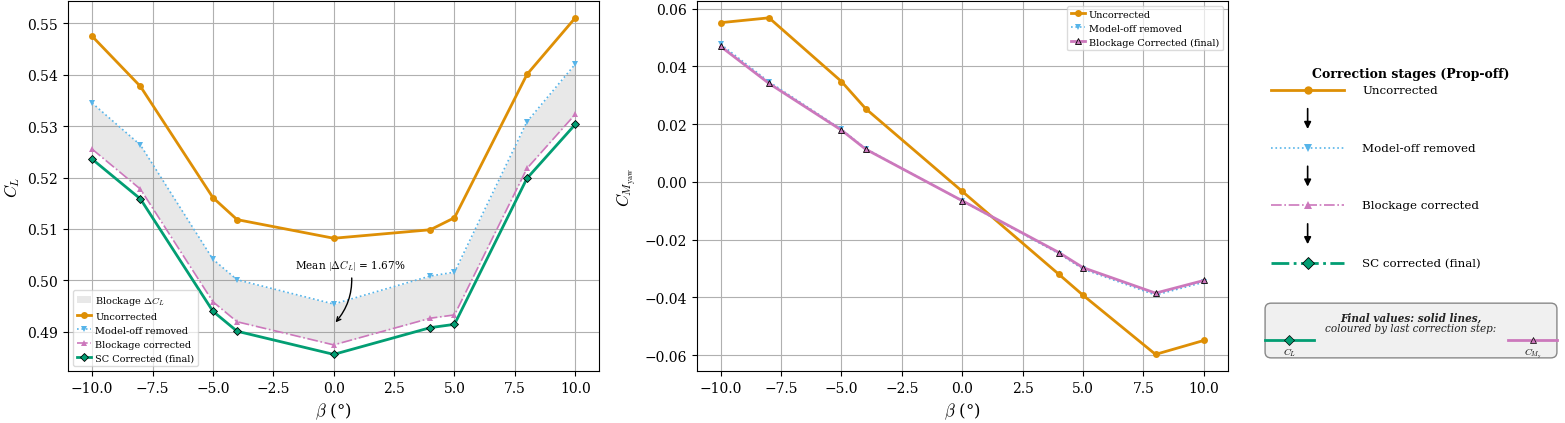

Saved: propoff_CL_CMyaw_beta_sweep.png

CL blockage correction effect — prop-off (Model-off removed → Blockage corrected):
   β (°)     Model-off   Blockage corr    Δ (signed)         |Δ|        Δ%
────────────────────────────────────────────────────────────────────────────────
   -10.0       0.53451         0.52554      -0.00897     0.00897     -1.7%
    -8.0       0.52634         0.51774      -0.00860     0.00860     -1.6%
    -5.0       0.50410         0.49583      -0.00827     0.00827     -1.6%
    -4.0       0.50011         0.49193      -0.00818     0.00818     -1.6%
     0.0       0.49539         0.48743      -0.00796     0.00796     -1.6%
     4.0       0.50084         0.49263      -0.00821     0.00821     -1.6%
     5.0       0.50159         0.49327      -0.00832     0.00832     -1.7%
     8.0       0.53088         0.52179      -0.00909     0.00909     -1.7%
    10.0       0.54210         0.53233      -0.00977     0.00977     -1.8%
──────────────────────────────────────────────

In [47]:
# ═══════════════════════════════════════════════════════════════════════════════
# ── Prop-off: CL and CMyaw β sweep with intermediate correction steps ──────────
# AoA=2.5, V=40, dR=0, dE=0
# ═══════════════════════════════════════════════════════════════════════════════

# ── Coefficient config ────────────────────────────────────────────────────────

_COEFF_CONFIG_BETA_OFF = [
    (
        r"$C_L$", 3,          # final style idx → SC green
        [
            ("Uncorrected",          "raw", "CL_uncorrected"),
            ("Model-off removed",    "raw", "CL"),
            ("Blockage corrected",   "raw", "CL_blockage_corr"),
            ("SC Corrected (final)", "fin", "CL_FINAL"),
        ]
    ),
    (
        r"$C_{M_\mathrm{yaw}}$", 2,   # final style idx → blockage purple
        [
            ("Uncorrected",                "raw", "CMyaw_uncorrected"),
            ("Model-off removed",          "raw", "CMyaw"),
            ("Blockage Corrected (final)", "fin", "CMyaw_FINAL"),
        ]
    ),
]

# Flow legend entries — only the stages that actually appear across both panels
_FIG_LEGEND_ENTRIES_BETA_OFF = [
    ("Uncorrected",          _STAGE_STYLES_OFF[0], False),
    ("Model-off removed",    _STAGE_STYLES_OFF[1], False),
    ("Blockage corrected",   _STAGE_STYLES_OFF[2], False),
    ("SC corrected (final)", _STAGE_STYLES_OFF[3], True),
]

# Footer swatches — one per coefficient, coloured by its final correction step
_FOOTER_FINALS_BETA_OFF = [
    (r"$C_L$",              _STAGE_STYLES_OFF[3]),   # SC    → green
    (r"$C_{M_\mathrm{y}}$", _STAGE_STYLES_OFF[2]),   # BLK   → purple
]

# ── Load & filter ─────────────────────────────────────────────────────────────

_df_off_beta = df_off[
    (df_off["V_round"]   == 40)  &
    (df_off["AoA_round"] == 2.5) &
    (df_off["dR"]        == 0)   &
    (df_off["dE"]        == 0)
].copy()

# Average duplicate AoS points
_df_off_beta = (
    _df_off_beta.groupby("AoS_round", as_index=False)
    .mean(numeric_only=True)
    .sort_values("AoS_round")
)

print(f"Prop-off β sweep: {len(_df_off_beta)} rows, "
      f"AoS range {_df_off_beta['AoS_round'].min():.1f}–{_df_off_beta['AoS_round'].max():.1f}")

_x_raw_off_beta = _df_off_beta["AoS_round"].to_numpy(dtype=float)
_x_fin_off_beta = _x_raw_off_beta   # no AoS_FINAL in dataset

# ── Blockage shading for CL panel: model-off → blockage corrected ─────────────
_y_mo_off  = _df_off_beta["CL"].to_numpy(dtype=float)
_y_bc_off  = _df_off_beta["CL_blockage_corr"].to_numpy(dtype=float)
_dpct_off  = np.abs((_y_bc_off - _y_mo_off) / _y_mo_off * 100)
_mpct_off  = _dpct_off.mean()

# Band midpoint at beta=0 for arrow tip
_x0_mask       = _x_raw_off_beta == 0
_band_mid_off  = float((_y_mo_off[_x0_mask] + _y_bc_off[_x0_mask]).mean() / 2)

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

for ax_idx, (ax, (ylabel, final_style_idx, stages)) in enumerate(
        zip(axes, _COEFF_CONFIG_BETA_OFF)):

    # Shading only on the CL panel (ax_idx == 0)
    if ax_idx == 0:
        ax.fill_between(
            _x_raw_off_beta, _y_mo_off, _y_bc_off,
            color="grey", alpha=0.18, linewidth=0,
            label=r"Blockage $\Delta C_L$",
            zorder=2,
        )

    for i, (label, x_key, col) in enumerate(stages):
        if col not in _df_off_beta.columns:
            print(f"  WARNING: '{col}' not found, skipping")
            continue

        x = _x_fin_off_beta if x_key == "fin" else _x_raw_off_beta
        y = _df_off_beta[col].to_numpy(dtype=float)
        fin = np.isfinite(x) & np.isfinite(y)

        if fin.sum() == 0:
            print(f"  WARNING: no finite data for {col}")
            continue

        is_final = (i == len(stages) - 1)
        is_start = (i == 0)

        style = (
            _STAGE_STYLES_OFF[final_style_idx] if is_final
            else _STAGE_STYLES_OFF[i]
        )

        ax.plot(
            x[fin], y[fin],
            marker=style["marker"],
            markersize=MS if not is_final else MS - 1,
            markerfacecolor=style["color"],
            markeredgecolor="black" if is_final else style["color"],
            markeredgewidth=0.6 if is_final else 0.0,
            linestyle="-" if is_final or is_start else style["linestyle"],
            color=style["color"],
            linewidth=2.0 if is_final or is_start else 1.2,
            label=label,
            zorder=4,
        )

    # Annotation on CL panel only
    if ax_idx == 0:
        # Text placed above all curves (y≈0.556), arrow curves down into band
        # midpoint at (β=0, y≈0.4914). Left-of-centre keeps right side clear
        # for the legend.
        ax.annotate(
            fr"Mean $|\Delta C_L|$ = {_mpct_off:.2f}%",
            xy=(0.0, _band_mid_off),
            xytext=(-1.6, 0.503),
            fontsize=7.5, color="black", ha="left", va="center", zorder=6,
            arrowprops=dict(
                arrowstyle="->", color="black", lw=1.0,
                connectionstyle="arc3,rad=-0.25",
            ),
        )

    ax.set_xlabel(r"$\beta$ (°)")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, loc="best", framealpha=0.7,
              handlelength=1.5, handletextpad=0.4, borderpad=0.4)
    ax.grid(True)

# draw_flow_legend defined in the prop-off AoA sweep cell above
leg_ax = draw_flow_legend(fig, _FIG_LEGEND_ENTRIES_BETA_OFF, _FOOTER_FINALS_BETA_OFF,
                          leg_left=LEG_LEFT)

if SHOW_TITLE:
    plt.suptitle(
        r"Prop-off correction stages — $V$ = 40 m/s, $\alpha$ = 2.5°, $\delta_r$ = 0°, $\delta_e$ = 0°",
        fontsize=12, y=1.02
    )

plt.tight_layout(rect=[0, 0, LEG_LEFT - 0.01, 1.0])
savefig(fig, "propoff_CL_CMyaw_beta_sweep", bbox_extra_artists=[leg_ax])
plt.show()
print("Saved: propoff_CL_CMyaw_beta_sweep.png")

# ── CL: magnitude difference between Model-off removed and Blockage corrected ─

_cl_compare_off = _df_off_beta[["AoS_round", "CL", "CL_blockage_corr"]].copy()
_cl_compare_off["ΔCL"]   =  _cl_compare_off["CL_blockage_corr"] - _cl_compare_off["CL"]
_cl_compare_off["Δ|CL|"] =  _cl_compare_off["ΔCL"].abs()
_cl_compare_off["Δ%"]    = (_cl_compare_off["ΔCL"] / _cl_compare_off["CL"].abs() * 100)

print("\nCL blockage correction effect — prop-off (Model-off removed → Blockage corrected):")
print(f"{'β (°)':>8}  {'Model-off':>12}  {'Blockage corr':>14}  {'Δ (signed)':>12}  {'|Δ|':>10}  {'Δ%':>8}")
print("─" * 80)
for _, row in _cl_compare_off.iterrows():
    print(f"{row['AoS_round']:>8.1f}  "
          f"{row['CL']:>12.5f}  "
          f"{row['CL_blockage_corr']:>14.5f}  "
          f"{row['ΔCL']:>12.5f}  "
          f"{row['Δ|CL|']:>10.5f}  "
          f"{row['Δ%']:>7.1f}%")
print("─" * 80)
print(f"{'Mean |Δ|':>69}  {_cl_compare_off['Δ|CL|'].mean():>10.5f}")
print(f"{'Max  |Δ|':>69}  {_cl_compare_off['Δ|CL|'].max():>10.5f}")
print(f"{'Mean |Δ%|':>69}  {_cl_compare_off['Δ%'].abs().mean():>9.1f}%")

# ── CMyaw: magnitude difference between Uncorrected and Model-off removed ──────

_cmyaw_compare = _df_off_beta[["AoS_round", "CMyaw_uncorrected", "CMyaw"]].copy()
_cmyaw_compare["ΔCMyaw"]   =  _cmyaw_compare["CMyaw"] - _cmyaw_compare["CMyaw_uncorrected"]
_cmyaw_compare["Δ|CMyaw|"] =  _cmyaw_compare["ΔCMyaw"].abs()
_cmyaw_compare["Δ%"]       = (_cmyaw_compare["ΔCMyaw"] / _cmyaw_compare["CMyaw_uncorrected"].abs() * 100)

print("\nCMyaw model-off correction effect:")
print(f"{'β (°)':>8}  {'Raw':>10}  {'Model-off removed':>18}  {'Δ (signed)':>12}  {'|Δ|':>10}  {'Δ%':>8}")
print("─" * 80)
for _, row in _cmyaw_compare.iterrows():
    print(f"{row['AoS_round']:>8.1f}  "
          f"{row['CMyaw_uncorrected']:>10.5f}  "
          f"{row['CMyaw']:>18.5f}  "
          f"{row['ΔCMyaw']:>12.5f}  "
          f"{row['Δ|CMyaw|']:>10.5f}  "
          f"{row['Δ%']:>7.1f}%")
print("─" * 80)
print(f"{'Mean |Δ|':>69}  {_cmyaw_compare['Δ|CMyaw|'].mean():>10.5f}")
print(f"{'Max  |Δ|':>69}  {_cmyaw_compare['Δ|CMyaw|'].max():>10.5f}")
print(f"{'Mean |Δ%|':>69}  {_cmyaw_compare['Δ%'].abs().mean():>9.1f}%")

---
---
## Prop-on
---


### Prop-on AoA sweep, $V=40$, $J=1.6, 2.4$ (NEW)


J=1.6: 5 rows, AoA range -5.0–8.0


C:\Users\douwe\AppData\Local\Temp\ipykernel_24560\1479232917.py:255: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, leg_left - 0.01, 1.0])


Saved figure to: c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\correction_comparison_plots\propon_4coeff_correction_stages_J1p6.pdf


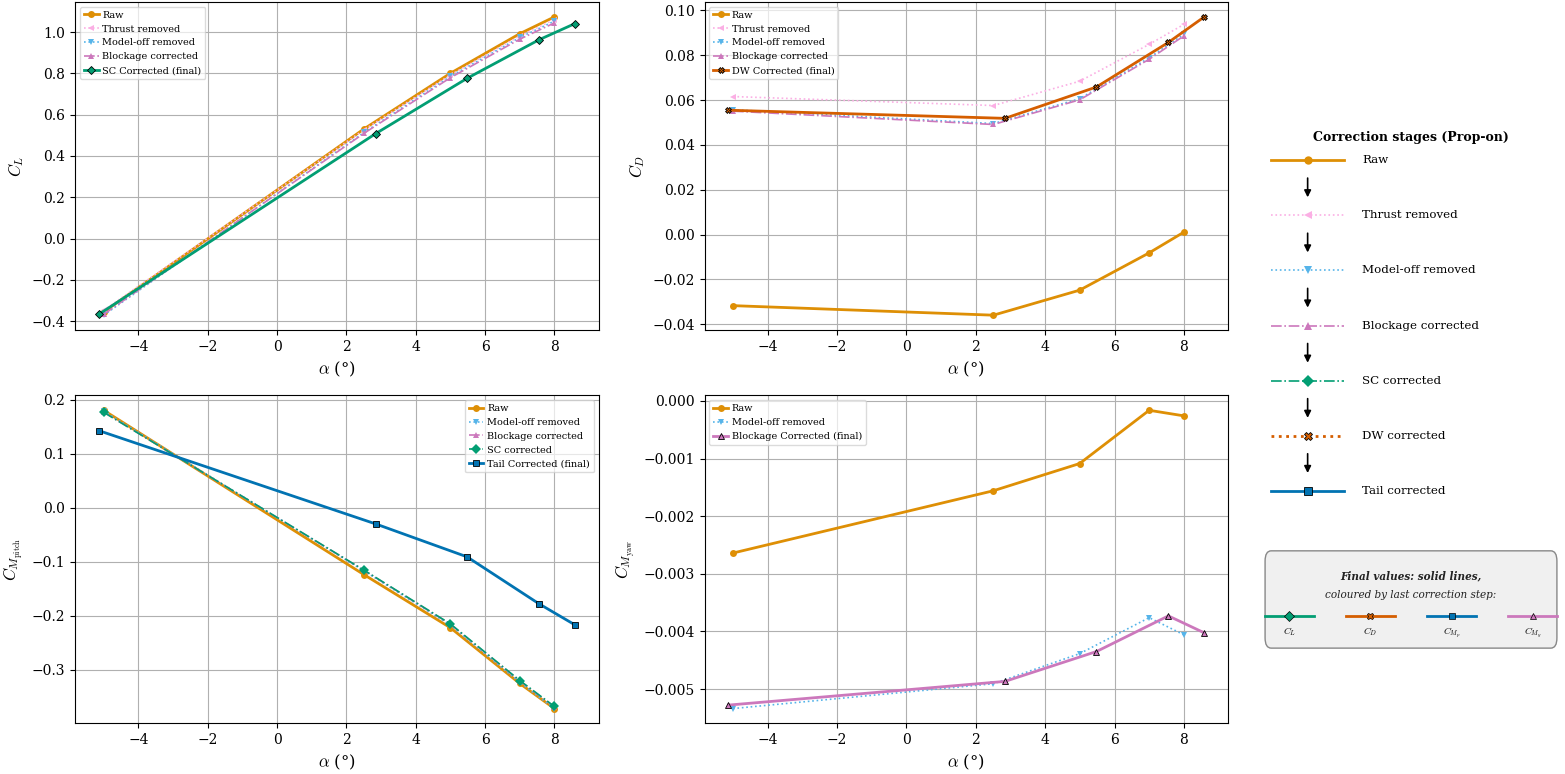

Saved: propon_4coeff_correction_stages_J1p6

J=2.4: 5 rows, AoA range -5.0–8.0


C:\Users\douwe\AppData\Local\Temp\ipykernel_24560\1479232917.py:255: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, leg_left - 0.01, 1.0])


Saved figure to: c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\correction_comparison_plots\propon_4coeff_correction_stages_J2p4.pdf


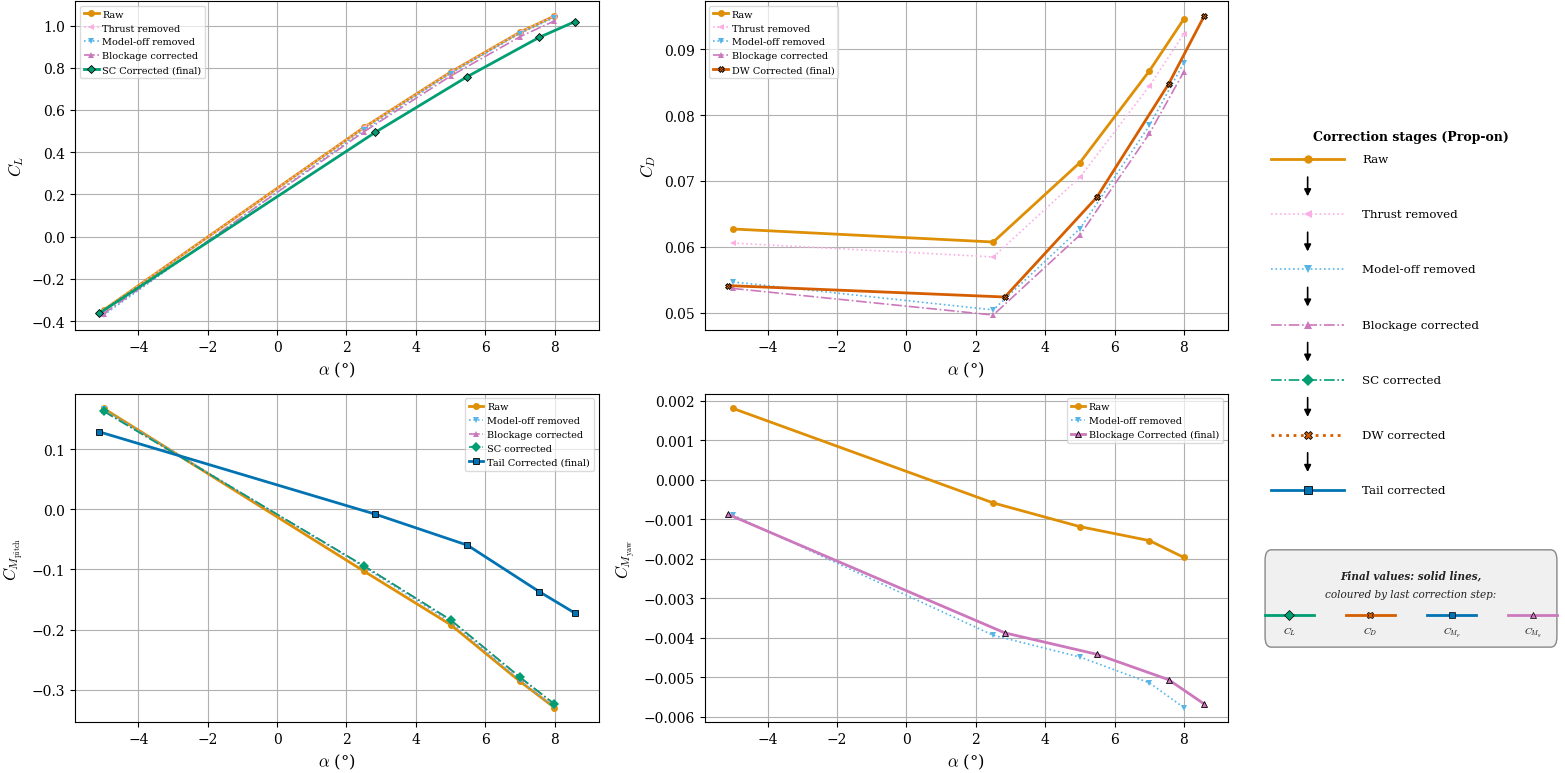

Saved: propon_4coeff_correction_stages_J2p4


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns


# ── Stage config ─────────────────────────────────────────────────────────────
J_VALUES_STAGES = [1.6, 2.4]
 
_COEFF_CONFIG_ON = [
    (
        r"$C_L$", 4, True,
        [
            ("Raw",                  "raw", "CL"),
            ("Thrust removed",       "raw", "CL_aero_EXP_uncorrected"),
            ("Model-off removed",    "raw", "CL_aero_EXP"),
            ("Blockage corrected",   "raw", "CL_aero_EXP_blockage_corr"),
            ("SC Corrected (final)", "fin", "CL_FINAL"),
        ]
    ),
    (
        r"$C_D$", 4, True,
        [
            ("Raw",                  "raw", "CD"),
            ("Thrust removed",       "raw", "CD_aero_EXP_uncorrected"),
            ("Model-off removed",    "raw", "CD_aero_EXP"),
            ("Blockage corrected",   "raw", "CD_aero_EXP_blockage_corr"),
            ("DW Corrected (final)", "fin", "CD_FINAL"),
        ]
    ),
    (
        r"$C_{M_\mathrm{pitch}}$", 5, False,
        [
            ("Raw",                    "raw", "CMpitch_uncorrected"),
            ("Model-off removed",      "raw", "CMpitch"),
            ("Blockage corrected",     "raw", "CMpitch_blockage_corr"),
            ("SC corrected",           "sc", "CMpitch_blockage_corr_sc_corr"),
            ("Tail Corrected (final)", "fin", "CMpitch_FINAL"),
        ]
    ),
    (
        r"$C_{M_\mathrm{yaw}}$", 3, False,
        [
            ("Raw",                        "raw", "CMyaw_uncorrected"),
            ("Model-off removed",          "raw", "CMyaw"),
            ("Blockage Corrected (final)", "fin", "CMyaw_FINAL"),
        ]
    ),
]
 
_STAGE_STYLES_ON = [
    dict(marker="o", linestyle="-",  color=COLORS[1]),   # 0 raw            orange
    dict(marker="<", linestyle=":",  color=COLORS[6]),   # 1 thrust removed pink
    dict(marker="v", linestyle=":",  color=COLORS[9]),   # 2 model-off      teal
    dict(marker="^", linestyle="-.", color=COLORS[4]),   # 3 blockage       purple
    dict(marker="D", linestyle="-.", color=COLORS[2]),   # 4 SC             green
    dict(marker="s", linestyle="-",  color=COLORS[0]),   # 5 tail/final     blue
]
_DW_STYLE = dict(marker="X", linestyle=":", color=COLORS[3])  # DW — dark red
 
# ── Figure-level legend entries (ordered, for flow arrow legend) ──────────────
# Each entry: (label, style_dict, is_final)
_FIG_LEGEND_ENTRIES = [
    ("Raw",                          _STAGE_STYLES_ON[0], False),
    ("Thrust removed",               _STAGE_STYLES_ON[1], False),
    ("Model-off removed",            _STAGE_STYLES_ON[2], False),
    ("Blockage corrected",           _STAGE_STYLES_ON[3], False),
    ("SC corrected",                 _STAGE_STYLES_ON[4], False),
    (r"DW corrected",               _DW_STYLE,           True),
    ("Tail corrected",              _STAGE_STYLES_ON[5], True),
]
 
def draw_flow_legend(fig, leg_entries, footer_finals, leg_left=0.795):
    from matplotlib.patches import FancyBboxPatch
 
    n_entries  = len(leg_entries)
    leg_ax = fig.add_axes([leg_left, 0.18, 0.19, 0.64])
    leg_ax.set_xlim(0, 1)
    leg_ax.set_ylim(0, 1)
    leg_ax.axis("off")
 
    # Title
    leg_ax.text(0.5, 1.0, "Correction stages (Prop-on)", ha="center", va="top",
                fontsize=9, fontweight="bold", transform=leg_ax.transAxes)
 
    # Flow entries
    flow_region = 0.70
    total_slots = n_entries + (n_entries - 1)
    slot_h      = flow_region / total_slots
    y_start     = 0.97
 
    entry_ys = []
    for k in range(total_slots):
        y_centre = y_start - k * slot_h - slot_h / 2
        if k % 2 == 0:
            entry_ys.append(y_centre)
 
    for idx, ((lbl, sty, is_fin), y_c) in enumerate(zip(leg_entries, entry_ys)):
        line_x = [0.04, 0.28]
        leg_ax.plot(line_x, [y_c, y_c],
                    color=sty["color"],
                    linestyle=sty["linestyle"],
                    linewidth=2.0 if is_fin or idx == 0 else 1.2,
                    transform=leg_ax.transAxes, clip_on=False)
        leg_ax.plot([np.mean(line_x)], [y_c],
                    marker=sty["marker"], markersize=6,
                    markerfacecolor=sty["color"],
                    markeredgecolor="black" if is_fin else sty["color"],
                    markeredgewidth=0.6 if is_fin else 0.0,
                    color=sty["color"],
                    transform=leg_ax.transAxes, clip_on=False, linestyle="none")
        leg_ax.text(0.34, y_c, lbl, va="center", ha="left",
                    fontsize=8.5, transform=leg_ax.transAxes)
 
        if idx < n_entries - 1:
            arrow_y_top    = y_c - slot_h * 0.55
            arrow_y_bottom = y_c - slot_h * 1.45
            leg_ax.annotate("",
                xy=(0.16, arrow_y_bottom), xytext=(0.16, arrow_y_top),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2, mutation_scale=10))
 
    # Footer box
    footer_box = FancyBboxPatch(
        (0.04, 0.01), 0.92, 0.15,
        boxstyle="round,pad=0.02", transform=leg_ax.transAxes,
        facecolor="#f0f0f0", edgecolor="#888888", linewidth=1.0,
        clip_on=False, zorder=2)
    leg_ax.add_patch(footer_box)
 
    leg_ax.text(0.5, 0.132, "Final values: solid lines,",
        ha="center", va="center", fontsize=7.5, fontstyle="italic",
        fontweight="bold", color="#222222", transform=leg_ax.transAxes, zorder=3)
    leg_ax.text(0.5, 0.094, "coloured by last correction step:",
        ha="center", va="center", fontsize=7.5, fontstyle="italic",
        color="#222222", transform=leg_ax.transAxes, zorder=3)
 
    n_sw    = len(footer_finals)
    swatch_y = 0.040
    for k, (lbl, sty) in enumerate(footer_finals):
        x_c = 0.1 + k * (0.8 / (n_sw - 1))
        leg_ax.plot([x_c - 0.08, x_c + 0.08], [swatch_y + 0.012, swatch_y + 0.012],
                    color=sty["color"], linewidth=2.0,
                    transform=leg_ax.transAxes, zorder=3, clip_on=False)
        leg_ax.plot([x_c], [swatch_y + 0.012],
                    marker=sty["marker"], markersize=5,
                    markerfacecolor=sty["color"],
                    markeredgecolor="black", markeredgewidth=0.5,
                    linestyle="none", color=sty["color"],
                    transform=leg_ax.transAxes, zorder=4, clip_on=False)
        leg_ax.text(x_c, swatch_y - 0.006, lbl,
                    ha="center", va="top", fontsize=7,
                    transform=leg_ax.transAxes, zorder=3)
 
    # Border
    for spine in ["top", "bottom", "left", "right"]:
        leg_ax.spines[spine].set_visible(True)
        leg_ax.spines[spine].set_linewidth(0.6)
        leg_ax.spines[spine].set_color("#cccccc")
 
    return leg_ax
 
 
# ── Plot ─────────────────────────────────────────────────────────────────────
for j_val in J_VALUES_STAGES:
    _df = df_on[
        (df_on["V_round"]   == 40) &
        (df_on["AoS_round"] == 0)  &
        (df_on["dR"]        == 0)  &
        (df_on["J_round"]   == j_val)
    ].copy().sort_values("AoA_round")
 
    if _df.empty:
        print(f"No data for J={j_val}")
        continue
 
    print(f"\nJ={j_val}: {len(_df)} rows, AoA range {_df['AoA'].min():.1f}–{_df['AoA'].max():.1f}")
 
    _x_raw = _df["AoA"].to_numpy(dtype=float)
    _x_fin = _df["AoA_FINAL"].to_numpy(dtype=float)
    # Add alongside _x_raw / _x_fin:
    _x_sc = _df["AoA_sc_corr"].to_numpy(dtype=float)
 
    # Wider figure: right ~22% reserved for legend
    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_COMP_GRID)
    axes = axes.flatten()
 
    for ax, (ylabel, final_style_idx, has_thrust, stages) in zip(axes, _COEFF_CONFIG_ON):
        for i, (label, x_key, col) in enumerate(stages):
            if col not in _df.columns:
                print(f"  WARNING: column '{col}' not found, skipping")
                continue

            # In the plotting dispatch:
            if   x_key == "fin": x = _x_fin
            elif x_key == "sc":  x = _x_sc
            else:                x = _x_raw
 
            x = _x_fin if x_key == "fin" else _x_raw
            y = _df[col].to_numpy(dtype=float)
            fin = np.isfinite(x) & np.isfinite(y)
 
            if fin.sum() == 0:
                print(f"  WARNING: no finite data for {col}")
                continue
 
            is_final = (i == len(stages) - 1)
            is_start = (i == 0)
            style_idx = i if has_thrust else (i + 1 if i > 0 else 0)
 
            style = (
                _STAGE_STYLES_ON[final_style_idx] if is_final and "DW" not in label
                else _DW_STYLE if "DW" in label
                else _STAGE_STYLES_ON[style_idx]
            )
 
            ax.plot(
                x[fin], y[fin],
                marker=style["marker"],
                markersize=MS if not is_final else MS - 1,
                markerfacecolor=style["color"],
                markeredgecolor="black" if is_final else style["color"],
                markeredgewidth=0.6 if is_final else 0.0,
                linestyle="-" if is_final or is_start else style["linestyle"],
                color=style["color"],
                linewidth=2.0 if is_final or is_start else 1.2,
                label=label,
            )
 
        ax.set_xlabel(r"$\alpha$ (°)")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=7, loc="best", framealpha=0.7,
                  handlelength=1.5, handletextpad=0.4, borderpad=0.4)
        ax.grid(True)
 
    # ── Right-side flow legend ────────────────────────────────────────────────
    _FOOTER_FINALS_ON = [
        (r"$C_L$",     _STAGE_STYLES_ON[4]),   # SC   → green
        (r"$C_D$",     _DW_STYLE),              # DW   → dark red
        (r"$C_{M_p}$", _STAGE_STYLES_ON[5]),   # Tail → blue
        (r"$C_{M_y}$", _STAGE_STYLES_ON[3]),   # BLK  → purple
    ]
    leg_left = 0.795
    leg_ax = draw_flow_legend(fig, _FIG_LEGEND_ENTRIES, _FOOTER_FINALS_ON, leg_left=leg_left)
 
    # ── Title & save ──────────────────────────────────────────────────────────
    if SHOW_TITLE:
        plt.suptitle(
            fr"Prop-on correction stages — $J$ = {j_val}, $V$ = 40 m/s, $\beta$ = 0°, $\delta_r$ = 0°",
            fontsize=12, y=1.01
        )
 
    plt.tight_layout(rect=[0, 0, leg_left - 0.01, 1.0])
 
    j_str = f"{j_val}".replace(".", "p")
    save_name = f"propon_4coeff_correction_stages_J{j_str}"
    savefig(fig, save_name, bbox_extra_artists=[leg_ax])
    plt.show()
    print(f"Saved: {save_name}")

---
###  Prop-on AoS sweep, $V=40$, $J=2$

J=2.0: 6 rows, AoS range -10.0–10.0


C:\Users\douwe\AppData\Local\Temp\ipykernel_24560\2783292268.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, LEG_LEFT - 0.01, 1.0])


Saved figure to: c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\correction_comparison_plots\propon_CL_CMyaw_beta_sweep_J2p0.pdf


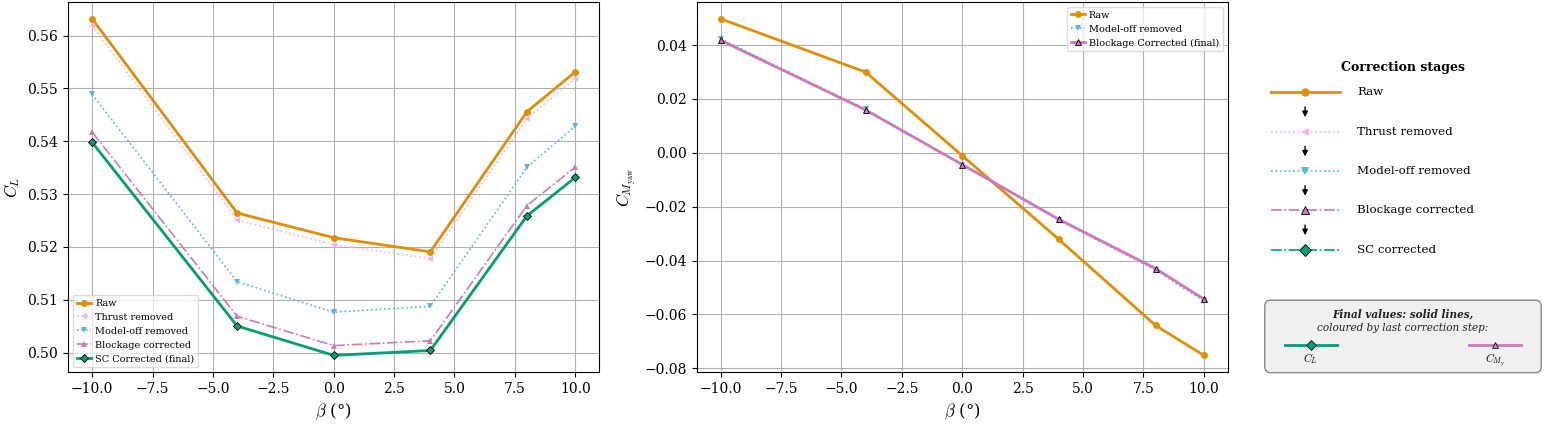


CL blockage correction effect — prop-on (Model-off removed → Blockage corrected):
   β (°)     Model-off   Blockage corr    Δ (signed)         |Δ|        Δ%
────────────────────────────────────────────────────────────────────────────────
   -10.0       0.54888         0.54174      -0.00714     0.00714     -1.3%
    -4.0       0.51343         0.50689      -0.00654     0.00654     -1.3%
     0.0       0.50765         0.50133      -0.00632     0.00632     -1.2%
     4.0       0.50877         0.50224      -0.00653     0.00653     -1.3%
     8.0       0.53510         0.52783      -0.00727     0.00727     -1.4%
    10.0       0.54284         0.53512      -0.00772     0.00772     -1.4%
────────────────────────────────────────────────────────────────────────────────
                                                             Mean |Δ|     0.00692
                                                             Max  |Δ|     0.00772
                                                            Mean |

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

_STAGE_STYLES_ON = [
    dict(marker="o", linestyle="-",  color=COLORS[1]),
    dict(marker="<", linestyle=":",  color=COLORS[6]),
    dict(marker="v", linestyle=":",  color=COLORS[9]),
    dict(marker="^", linestyle="-.", color=COLORS[4]),
    dict(marker="D", linestyle="-.", color=COLORS[2]),
    dict(marker="s", linestyle="-",  color=COLORS[0]),
]
_DW_STYLE = dict(marker="X", linestyle=":", color=COLORS[3])
 
_COEFF_CONFIG_BETA_ON = [
    (
        r"$C_L$", 4, True,
        [
            ("Raw",                  "raw", "CL"),
            ("Thrust removed",       "raw", "CL_aero_EXP_uncorrected"),
            ("Model-off removed",    "raw", "CL_aero_EXP"),
            ("Blockage corrected",   "raw", "CL_aero_EXP_blockage_corr"),
            ("SC Corrected (final)", "fin", "CL_FINAL"),
        ]
    ),
    (
        r"$C_{M_\mathrm{yaw}}$", 3, False,
        [
            ("Raw",                        "raw", "CMyaw_uncorrected"),
            ("Model-off removed",          "raw", "CMyaw"),
            ("Blockage Corrected (final)", "fin", "CMyaw_FINAL"),
        ]
    ),
]
 
_FOOTER_FINALS = [
    (r"$C_L$",              _STAGE_STYLES_ON[4]),
    (r"$C_{M_\mathrm{y}}$", _STAGE_STYLES_ON[3]),
]
 
def draw_right_legend(fig, footer_finals, leg_left=LEG_LEFT):
    leg_ax = fig.add_axes([leg_left, 0.15, 0.18, 0.70])
    leg_ax.set_xlim(0, 1)
    leg_ax.set_ylim(0, 1)
    leg_ax.axis("off")
 
    leg_ax.text(0.5, 0.98, "Correction stages", ha="center", va="top",
                fontsize=9, fontweight="bold", transform=leg_ax.transAxes)
 
    relevant = [
        ("Raw",                _STAGE_STYLES_ON[0], False),
        ("Thrust removed",     _STAGE_STYLES_ON[1], False),
        ("Model-off removed",  _STAGE_STYLES_ON[2], False),
        ("Blockage corrected", _STAGE_STYLES_ON[3], True),
        ("SC corrected",       _STAGE_STYLES_ON[4], True),
    ]
 
    n     = len(relevant)
    y_top = 0.88
    y_bot = 0.38
    step  = (y_top - y_bot) / (n - 1)
 
    for i, (lbl, sty, is_fin) in enumerate(relevant):
        y_c    = y_top - i * step
        line_x = [0.04, 0.28]
        leg_ax.plot(line_x, [y_c, y_c],
                    color=sty["color"],
                    linestyle=sty["linestyle"],   # taken from definition, NOT forced solid
                    linewidth=2.0 if i == 0 else 1.2,
                    transform=leg_ax.transAxes, clip_on=False)
        leg_ax.plot([np.mean(line_x)], [y_c],
                    marker=sty["marker"], markersize=6,
                    markerfacecolor=sty["color"],
                    markeredgecolor="black" if is_fin else sty["color"],
                    markeredgewidth=0.6 if is_fin else 0.0,
                    color=sty["color"],
                    transform=leg_ax.transAxes, clip_on=False, linestyle="none")
        leg_ax.text(0.34, y_c, lbl, va="center", ha="left",
                    fontsize=8.5, transform=leg_ax.transAxes)
 
        # Arrow to next entry
        if i < n - 1:
            y_next = y_top - (i + 1) * step
            y_arrow_start = y_c - step * 0.3
            y_arrow_end   = y_next + step * 0.3
            leg_ax.annotate("",
                xy=(0.16, y_arrow_end), xytext=(0.16, y_arrow_start),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.0, mutation_scale=8))
 
    footer_box = FancyBboxPatch(
        (0.04, 0.01), 0.92, 0.19,
        boxstyle="round,pad=0.02", transform=leg_ax.transAxes,
        facecolor="#f0f0f0", edgecolor="#888888", linewidth=1.0,
        clip_on=False, zorder=2)
    leg_ax.add_patch(footer_box)
 
    leg_ax.text(0.5, 0.175, "Final values: solid lines,",
        ha="center", va="center", fontsize=7.5, fontstyle="italic",
        fontweight="bold", color="#222222", transform=leg_ax.transAxes, zorder=3)
    leg_ax.text(0.5, 0.132, "coloured by last correction step:",
        ha="center", va="center", fontsize=7.5, fontstyle="italic",
        color="#222222", transform=leg_ax.transAxes, zorder=3)
 
    n_sw     = len(footer_finals)
    swatch_y = 0.065
    for k, (lbl, sty) in enumerate(footer_finals):
        x_c = 0.18 + k * (0.64 / (n_sw - 1))
        leg_ax.plot([x_c - 0.09, x_c + 0.09], [swatch_y + 0.014, swatch_y + 0.014],
                    color=sty["color"], linewidth=2.0,
                    transform=leg_ax.transAxes, zorder=3, clip_on=False)
        leg_ax.plot([x_c], [swatch_y + 0.014],
                    marker=sty["marker"], markersize=5,
                    markerfacecolor=sty["color"],
                    markeredgecolor="black", markeredgewidth=0.5,
                    linestyle="none", color=sty["color"],
                    transform=leg_ax.transAxes, zorder=4, clip_on=False)
        leg_ax.text(x_c, swatch_y - 0.008, lbl,
                    ha="center", va="top", fontsize=8,
                    transform=leg_ax.transAxes, zorder=3)
 
    for spine in ["top", "bottom", "left", "right"]:
        leg_ax.spines[spine].set_visible(True)
        leg_ax.spines[spine].set_linewidth(0.6)
        leg_ax.spines[spine].set_color("#cccccc")
 
# ── Load & filter ─────────────────────────────────────────────────────────────
 
_df = df_on[
    (df_on["V_round"]   == 40)  &
    (df_on["AoA_round"] == 2.5) &
    (df_on["dR"]        == 0)   &
    (df_on["J_round"]   == 2.0)
].copy()
 
# Average duplicate AoS points
_df = (
    _df.groupby("AoS_round", as_index=False)
    .mean(numeric_only=True)
    .sort_values("AoS_round")
)
 
print(f"J=2.0: {len(_df)} rows, AoS range {_df['AoS_round'].min():.1f}–{_df['AoS_round'].max():.1f}")
 
_x_raw = _df["AoS_round"].to_numpy(dtype=float)
_x_fin = _x_raw   # no AoS_FINAL in dataset
 
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
 
for ax, (ylabel, final_style_idx, has_thrust, stages) in zip(axes, _COEFF_CONFIG_BETA_ON):
    for i, (label, x_key, col) in enumerate(stages):
        if col not in _df.columns:
            print(f"  WARNING: '{col}' not found, skipping")
            continue
 
        x = _x_fin if x_key == "fin" else _x_raw
        y = _df[col].to_numpy(dtype=float)
        fin = np.isfinite(x) & np.isfinite(y)
        if fin.sum() == 0:
            print(f"  WARNING: no finite data for {col}")
            continue
 
        is_final  = (i == len(stages) - 1)
        is_start  = (i == 0)
        style_idx = i if has_thrust else (i + 1 if i > 0 else 0)
 
        style = (
            _STAGE_STYLES_ON[final_style_idx] if is_final and "DW" not in label
            else _DW_STYLE if "DW" in label
            else _STAGE_STYLES_ON[style_idx]
        )
 
        ax.plot(
            x[fin], y[fin],
            marker=style["marker"],
            markersize=MS if not is_final else MS - 1,
            markerfacecolor=style["color"],
            markeredgecolor="black" if is_final else style["color"],
            markeredgewidth=0.6 if is_final else 0.0,
            linestyle="-" if is_final or is_start else style["linestyle"],
            color=style["color"],
            linewidth=2.0 if is_final or is_start else 1.2,
            label=label,
        )
 
    ax.set_xlabel(r"$\beta$ (°)")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, loc="best", framealpha=0.7,
              handlelength=1.5, handletextpad=0.4, borderpad=0.4)
    ax.grid(True)
 
draw_right_legend(fig, _FOOTER_FINALS, leg_left=LEG_LEFT)
 
if SHOW_TITLE:
    plt.suptitle(
        r"Prop-on correction stages — $J$ = 2.0, $V$ = 40 m/s, $\alpha$ = 2.5°, $\delta_r$ = 0°",
        fontsize=12, y=1.02
    )
 
plt.tight_layout(rect=[0, 0, LEG_LEFT - 0.01, 1.0])
savefig(fig, "propon_CL_CMyaw_beta_sweep_J2p0")
plt.show()

# ── CL: magnitude difference between Model-off removed and Blockage corrected ─

_cl_compare_on = _df[["AoS_round", "CL_aero_EXP", "CL_aero_EXP_blockage_corr"]].copy()
_cl_compare_on["ΔCL"]   =  _cl_compare_on["CL_aero_EXP_blockage_corr"] - _cl_compare_on["CL_aero_EXP"]
_cl_compare_on["Δ|CL|"] =  _cl_compare_on["ΔCL"].abs()
_cl_compare_on["Δ%"]    = (_cl_compare_on["ΔCL"] / _cl_compare_on["CL_aero_EXP"].abs() * 100)

print("\nCL blockage correction effect — prop-on (Model-off removed → Blockage corrected):")
print(f"{'β (°)':>8}  {'Model-off':>12}  {'Blockage corr':>14}  {'Δ (signed)':>12}  {'|Δ|':>10}  {'Δ%':>8}")
print("─" * 80)
for _, row in _cl_compare_on.iterrows():
    print(f"{row['AoS_round']:>8.1f}  "
          f"{row['CL_aero_EXP']:>12.5f}  "
          f"{row['CL_aero_EXP_blockage_corr']:>14.5f}  "
          f"{row['ΔCL']:>12.5f}  "
          f"{row['Δ|CL|']:>10.5f}  "
          f"{row['Δ%']:>7.1f}%")
print("─" * 80)
print(f"{'Mean |Δ|':>69}  {_cl_compare_on['Δ|CL|'].mean():>10.5f}")
print(f"{'Max  |Δ|':>69}  {_cl_compare_on['Δ|CL|'].max():>10.5f}")
print(f"{'Mean |Δ%|':>69}  {_cl_compare_on['Δ%'].abs().mean():>9.1f}%")



---
###  Prop-on AoS sweep, $V=40$, $J=2$ (only CL)

J=2.0: 6 rows, AoS range -10.0–10.0
Saved figure to: c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\correction_comparison_plots\propon_CL_beta_sweep_J2p0.pdf


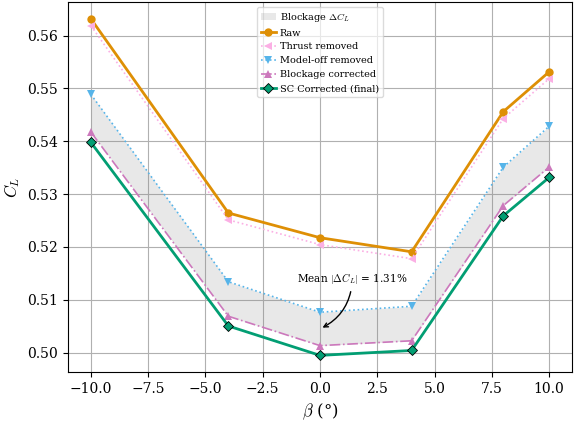

In [50]:
_STAGE_STYLES_ON = [
    dict(marker="o", linestyle="-",  color=COLORS[1]),
    dict(marker="<", linestyle=":",  color=COLORS[6]),
    dict(marker="v", linestyle=":",  color=COLORS[9]),
    dict(marker="^", linestyle="-.", color=COLORS[4]),
    dict(marker="D", linestyle="-.", color=COLORS[2]),
    dict(marker="s", linestyle="-",  color=COLORS[0]),
]

MS = 6   # marker size

_COEFF_CONFIG_CL_ONLY = [
    (
        r"$C_L$", 4, True,
        [
            ("Raw",                  "raw", "CL"),
            ("Thrust removed",       "raw", "CL_aero_EXP_uncorrected"),
            ("Model-off removed",    "raw", "CL_aero_EXP"),
            ("Blockage corrected",   "raw", "CL_aero_EXP_blockage_corr"),
            ("SC Corrected (final)", "fin", "CL_FINAL"),
        ]
    ),
]

# ── Load & filter ─────────────────────────────────────────────────────────────
_df = df_on[
    (df_on["V_round"]   == 40)  &
    (df_on["AoA_round"] == 2.5) &
    (df_on["dR"]        == 0)   &
    (df_on["J_round"]   == 2.0)
].copy()

_df = (
    _df.groupby("AoS_round", as_index=False)
    .mean(numeric_only=True)
    .sort_values("AoS_round")
)

print(f"J=2.0: {len(_df)} rows, AoS range {_df['AoS_round'].min():.1f}–{_df['AoS_round'].max():.1f}")

_x_raw = _df["AoS_round"].to_numpy(dtype=float)
_x_fin = _x_raw

# ── Blockage shading: model-off → blockage corrected ─────────────────────────
_y_modeloff = _df["CL_aero_EXP"].to_numpy(dtype=float)
_y_blockage = _df["CL_aero_EXP_blockage_corr"].to_numpy(dtype=float)
_delta_pct  = np.abs((_y_blockage - _y_modeloff) / _y_modeloff * 100)
_mean_pct   = _delta_pct.mean()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

ylabel, final_style_idx, has_thrust, stages = _COEFF_CONFIG_CL_ONLY[0]


color_an=COLORS[4]
color_an = "grey"

# Shaded band drawn first so all lines sit on top
# COLORS[4] (purple/violet in colorblind palette) works well — neutral,
# not used by any of the five stage lines, clearly visible at alpha=0.18
ax.fill_between(
    _x_raw, _y_modeloff, _y_blockage,
    color=color_an, alpha=0.18, linewidth=0,
    label=r"Blockage $\Delta C_L$",
    zorder=2,
)

for i, (label, x_key, col) in enumerate(stages):
    if col not in _df.columns:
        print(f"  WARNING: '{col}' not found, skipping")
        continue

    x = _x_fin if x_key == "fin" else _x_raw
    y = _df[col].to_numpy(dtype=float)
    fin = np.isfinite(x) & np.isfinite(y)
    if fin.sum() == 0:
        print(f"  WARNING: no finite data for {col}")
        continue

    is_final  = (i == len(stages) - 1)
    is_start  = (i == 0)
    style_idx = i if has_thrust else (i + 1 if i > 0 else 0)

    style = (
        _STAGE_STYLES_ON[final_style_idx] if is_final
        else _STAGE_STYLES_ON[style_idx]
    )

    ax.plot(
        x[fin], y[fin],
        marker=style["marker"],
        markersize=MS if not is_final else MS - 1,
        markerfacecolor=style["color"],
        markeredgecolor="black" if is_final else style["color"],
        markeredgewidth=0.6 if is_final else 0.0,
        linestyle="-" if is_final or is_start else style["linestyle"],
        color=style["color"],
        linewidth=2.0 if is_final or is_start else 1.2,
        label=label,
        zorder=4,
    )

# ── Annotation ────────────────────────────────────────────────────────────────
# Arrow tip: midpoint of the band at β=0 (~0.5045)
# Text: placed at (β=3.5, y=0.4935) — below the SC final line, clear of all
# curves, with a gentle arc curving up-left into the band.
# Colour matches the shading (COLORS[4]) so it reads as part of the same element.
_y_mo_at0  = float(_y_modeloff[_x_raw == 0][0])
_y_bc_at0  = float(_y_blockage[_x_raw == 0][0])
_band_mid0 = (_y_mo_at0 + _y_bc_at0) / 2   # ~0.5045

color_an=COLORS[4]
color_an = "black"

ax.annotate(
    fr"Mean $|\Delta C_L|$ = {_mean_pct:.2f}%",
    xy=(0.0, _band_mid0),
    xytext=(-1, 0.514),
    fontsize=7.5, color=color_an, ha="left", va="center", zorder=6,
    arrowprops=dict(
        arrowstyle="->", color=color_an, lw=1.0,
        connectionstyle="arc3,rad=-0.30",
    ),
)

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(ylabel)
ax.legend(fontsize=7, loc="best", framealpha=0.7,
          handlelength=1.5, handletextpad=0.4, borderpad=0.4)
ax.grid(True)

if SHOW_TITLE:
    ax.set_title(
        r"Prop-on $C_L$ correction stages — $J$ = 2.0, $V$ = 40 m/s, "
        r"$\alpha$ = 2.5°, $\delta_r$ = 0°"
    )

plt.tight_layout()
savefig(fig, "propon_CL_beta_sweep_J2p0")
plt.show()

---
---
# Model off surfaces

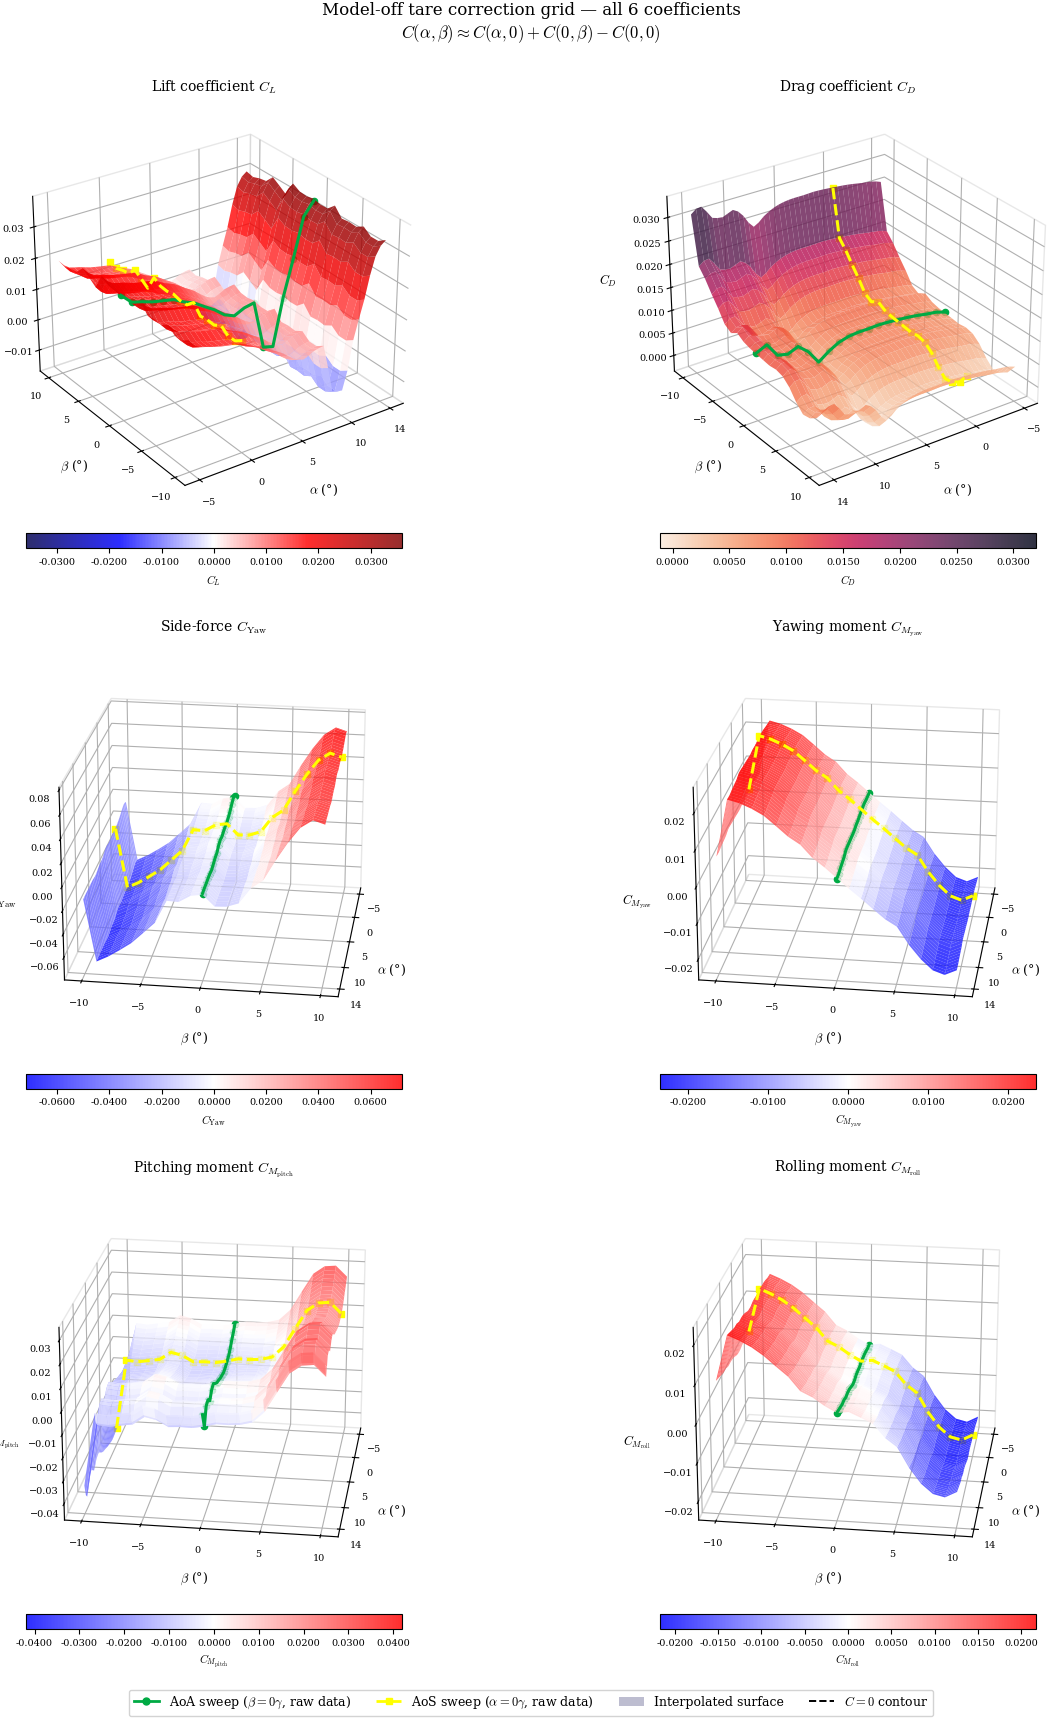

In [51]:



# ── Model-off tare correction grid — 3D surfaces, all 6 coefficients ──────────
# Surface: C(α,β) ≈ C(α,0) + C(0,β) − C(0,0)  (additive cross approximation)
# Raw input sweeps overlaid as coloured lines.
#
# Camera orientation per row:
#   Row 1 — CL, CD       : α is primary driver; azim=+55 puts low-α (low drag/lift)
#                           toward viewer, high-α toward the back.
#   Rows 2-3 — CYaw, CMpitch, CMroll, CMyaw : β is primary driver; azim=8 puts
#                           the β axis front-to-back so the full sideslip range is
#                           visible; α runs left-right as a secondary axis.
#
# Colormaps:
#   vlag     (diverging, zero-centred) → CL, CMpitch
#   coolwarm (diverging, zero-centred) → CYaw, CMroll, CMyaw
#   flare    (sequential)              → CD (always positive)
import pandas as pd  
from matplotlib.lines import Line2D
import matplotlib.patches

# ── Load correction grid ───────────────────────────────────────────────────────
_df_mo = pd.read_csv(r"CORRECTIONS_FINAL\MODEL_OFF_DATA\model_off_corrections_grid.csv")

# raw AoA sweep (β = 0°) — left block of modelOffData.xlsx
_df_aoa_raw = pd.read_excel(
    r"CORRECTIONS_FINAL\MODEL_OFF_DATA\modelOffData.xlsx",
    sheet_name="Sheet1", header=10, usecols="A:H"
)
_df_aoa_raw.columns = ["AoA [deg]","AoS [deg]","CD","CYaw","CL","CMroll","CMpitch","CMyaw"]
for _c in _df_aoa_raw.columns:
    _df_aoa_raw[_c] = pd.to_numeric(_df_aoa_raw[_c], errors="coerce")
_df_aoa_raw = _df_aoa_raw.dropna(subset=["AoA [deg]","AoS [deg]"]).sort_values("AoA [deg]")

# raw AoS sweep (α = 0°) — right block of modelOffData.xlsx
_df_aos_raw = pd.read_excel(
    r"CORRECTIONS_FINAL\MODEL_OFF_DATA\modelOffData.xlsx",
    sheet_name="Sheet1", header=10, usecols="J:Q"
)
_df_aos_raw.columns = ["AoA [deg]","AoS [deg]","CD","CYaw","CL","CMroll","CMpitch","CMyaw"]
for _c in _df_aos_raw.columns:
    _df_aos_raw[_c] = pd.to_numeric(_df_aos_raw[_c], errors="coerce")
_df_aos_raw = _df_aos_raw.dropna(subset=["AoA [deg]","AoS [deg]"]).sort_values("AoS [deg]")


# ── Grid ──────────────────────────────────────────────────────────────────────
_aoa_vals = np.array(sorted(_df_mo["AoA [deg]"].unique()))
_aos_vals = np.array(sorted(_df_mo["AoS [deg]"].unique()))
_AoA_grid, _AoS_grid = np.meshgrid(_aoa_vals, _aos_vals)

def _make_Z(coeff):
    return (_df_mo.pivot(index="AoS [deg]", columns="AoA [deg]", values=coeff)
                  .reindex(index=_aos_vals, columns=_aoa_vals)
                  .to_numpy(dtype=float))

# ── Colormaps ─────────────────────────────────────────────────────────────────
_cmap_CL  = plt.get_cmap("seismic")
_cmap_CD  = sns.color_palette("rocket_r", as_cmap=True)
_cmap_div = plt.get_cmap("bwr")

_COL_AOA = "#00AA44"
_COL_AOS = "#FFFF00"

# (csv_col, subplot title, z-label, cmap, elev, azim, inv_x, inv_y, draw_C0_contour)
_MO_COEFF_CONFIG = [
    ("CL",      r"Lift coefficient $C_L$",                  r"$C_L$",                  _cmap_CL,  28, 235, False, False, False ),
    ("CD",      r"Drag coefficient $C_D$",                  r"$C_D$",                  _cmap_CD,  28, 235, True,  True,  False),
    ("CYaw",    r"Side-force $C_\mathrm{Yaw}$",             r"$C_\mathrm{Yaw}$",       _cmap_div, 22,   8, False, False, False),
    ("CMyaw",   r"Yawing moment $C_{M_\mathrm{yaw}}$",      r"$C_{M_\mathrm{yaw}}$",   _cmap_div, 22,   8, False, False, False ),
    ("CMpitch", r"Pitching moment $C_{M_\mathrm{pitch}}$",  r"$C_{M_\mathrm{pitch}}$", _cmap_div, 22,   8, False, False, False ),
    ("CMroll",  r"Rolling moment $C_{M_\mathrm{roll}}$",    r"$C_{M_\mathrm{roll}}$",  _cmap_div, 22,   8, False, False, False ),
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, subplot_kw={"projection": "3d"}, figsize=(15, 17))
axes = axes.flatten()

for ax, (coeff, title, ylabel, cmap, elev, azim, inv_x, inv_y, do_contour) in \
        zip(axes, _MO_COEFF_CONFIG):

    Z = _make_Z(coeff)
    vmin, vmax = np.nanmin(Z), np.nanmax(Z)
    _is_div = (cmap is not _cmap_CD)
    if _is_div:
        _bound = max(abs(vmin), abs(vmax))
        vmin, vmax = -_bound, _bound

    surf = ax.plot_surface(_AoA_grid, _AoS_grid, Z,
                           cmap=cmap, vmin=vmin, vmax=vmax,
                           alpha=0.82, edgecolor="none", rcount=80, ccount=80)

    # C = 0 contour line (only where zero crossing is physically meaningful)
    if do_contour:
        try:
            cs = ax.contour(_AoA_grid, _AoS_grid, Z,
                            levels=[0], zdir='z', offset=0,
                            colors='k', linewidths=1.6, linestyles='--')
            for coll in cs.collections:   # force full opacity — matches legend
                coll.set_alpha(1.0)
        except Exception:
            pass

    # AoA sweep (β = 0°)
    _xa  = _df_aoa_raw["AoA [deg]"].to_numpy(float)
    _za  = _df_aoa_raw[coeff].to_numpy(float)
    _fin = np.isfinite(_xa) & np.isfinite(_za)

    _z_offset = 0.002 * (vmax - vmin)

    ax.plot(_xa[_fin], np.zeros_like(_xa[_fin]), _za[_fin] + _z_offset,
            color=_COL_AOA, linewidth=2.2, zorder=5)
    ax.scatter(_xa[_fin], np.zeros_like(_xa[_fin]), _za[_fin] + _z_offset,
            color=_COL_AOA, s=20, marker="o", zorder=6, depthshade=False)
    
    # AoS sweep (α = 0°)
    _yb   = _df_aos_raw["AoS [deg]"].to_numpy(float)
    _zb   = _df_aos_raw[coeff].to_numpy(float)
    _fin2 = np.isfinite(_yb) & np.isfinite(_zb)
    ax.plot(np.zeros_like(_yb[_fin2]), _yb[_fin2], _zb[_fin2] + _z_offset,
            color=_COL_AOS, linewidth=2.2, linestyle="--", zorder=5)
    ax.scatter(np.zeros_like(_yb[_fin2]), _yb[_fin2], _zb[_fin2] + _z_offset,
            color=_COL_AOS, s=20, marker="s", zorder=6, depthshade=False)

    # clean panes and grid
    for _pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        _pane.fill = False
        _pane.set_edgecolor("0.82")
    ax.grid(True, color="0.88", linewidth=0.4)

    ax.set_xticks([-5, 0, 5, 10, 14])
    ax.set_yticks([-10, -5, 0, 5, 10])
    ax.set_xlabel(r"$\alpha$ (°)", fontsize=9, labelpad=4)
    ax.set_ylabel(r"$\beta$ (°)",  fontsize=9, labelpad=4)
    ax.set_zlabel(ylabel,          fontsize=9, labelpad=6)
    ax.xaxis.set_rotate_label(False)
    ax.yaxis.set_rotate_label(False)
    ax.zaxis.set_rotate_label(False)
    ax.set_title(title, fontsize=10, pad=6)
    ax.tick_params(labelsize=7, pad=1)
    ax.view_init(elev=elev, azim=azim)
    if inv_x: ax.invert_xaxis()
    if inv_y: ax.invert_yaxis()

    cb = fig.colorbar(surf, ax=ax, shrink=0.45, pad=0.04,
                      aspect=25, format="%.4f", location="bottom")
    cb.ax.tick_params(labelsize=7)
    cb.set_label(ylabel, fontsize=8)

# ── Shared legend ─────────────────────────────────────────────────────────────
_legend_handles = [
    Line2D([0],[0], color=_COL_AOA, lw=2, marker="o", ms=5,
           label=r"AoA sweep ($\beta=0°$, raw data)"),
    Line2D([0],[0], color=_COL_AOS, lw=2, marker="s", ms=5, ls="--",
           label=r"AoS sweep ($\alpha=0°$, raw data)"),
    matplotlib.patches.Patch(facecolor="#8888AA", alpha=0.55,
                              label="Interpolated surface"),
    Line2D([0],[0], color="k", lw=1.4, ls="--",
           label=r"$C=0$ contour"),
]
fig.legend(handles=_legend_handles, loc="lower center", ncol=4, fontsize=9,
           framealpha=0.85, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    r"Model-off tare correction grid — all 6 coefficients" "\n"
    r"$C(\alpha,\beta)\approx C(\alpha,0)+C(0,\beta)-C(0,0)$",
    fontsize=12, y=1.002)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "modeloff_grid_surfaces_all6.png"),
            dpi=SAVE_RES, bbox_inches="tight", facecolor="white")
plt.show()